In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
# Read data
predata_003=pd.read_csv("D:/Man/Earth and Environment/EART60702_project2_group3/dataset/003_manchester_processed.csv")
predata_003

,time,TREFMXAV_U,FLNS,FSNS,PRECT,PRSN,QBOT,TREFHT,UBOT,VBOT,lat,lon,year,month,day,dayofyear
0,2006-01-02,9.62585,41.925180,25.926952,4.663135e-09,4.781004e-17,0.004769,5.99288,3.878579,1.394184,53.246075,357.5,2006,1,2,2
1,2006-01-03,11.32113,8.905806,10.946910,8.046593e-08,1.295726e-16,0.006271,7.99865,1.788157,3.821703,53.246075,357.5,2006,1,3,3
2,2006-01-04,11.13796,16.511415,6.405902,2.910936e-09,4.094447e-16,0.005782,8.07380,0.804845,-2.299140,53.246075,357.5,2006,1,4,4
3,2006-01-05,8.97110,29.948362,9.315041,7.432505e-11,0.000000e+00,0.004277,5.24767,-1.100267,-1.258029,53.246075,357.5,2006,1,5,5
4,2006-01-06,7.74090,19.064156,7.941241,6.894238e-12,0.000000e+00,0.003990,4.91378,-0.706321,-0.938421,53.246075,357.5,2006,1,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26320,2080-12-27,13.70907,55.167490,30.543959,4.768826e-08,0.000000e+00,0.006020,8.10858,1.665078,-1.866844,53.246075,357.5,2080,12,362,362
26321,2080-12-28,12.05993,33.668793,15.180238,1.048248e-08,0.000000e+00,0.005895,6.59475,-0.422336,2.654144,53.246075,357.5,2080,12,363,363
26322,2080-12-29,12.36710,20.443943,15.585098,1.590194e-09,0.000000e+00,0.006381,10.09332,0.827862,3.980862,53.246075,357.5,2080,12,364,364
26323,2080-12-30,10.64187,33.174114,18.295568,9.272739e-12,0.000000e+00,0.005410,7.73852,0.223743,3.058934,53.246075,357.5,2080,12,365,365


In [3]:
predata_003.describe()

,TREFMXAV_U,FLNS,FSNS,PRECT,PRSN,QBOT,TREFHT,UBOT,VBOT,lat,lon,year,month,day,dayofyear
count,26325.000000,26325.000000,26325.000000,2.632500e+04,2.632500e+04,26325.000000,26325.000000,26325.000000,26325.000000,2.632500e+04,26325.0,26325.000000,26325.000000,26325.000000,26325.000000
mean,15.564192,42.566436,95.158536,3.471725e-08,3.171354e-10,0.006502,11.632755,1.204115,1.533372,5.324608e+01,357.5,2042.957075,6.508642,182.677835,182.677835
std,5.230989,21.260652,74.238863,5.037079e-08,4.798466e-09,0.002127,4.986377,3.077605,2.955107,1.388427e-11,0.0,21.638511,3.474620,106.253761,106.253761
min,1.003200,0.611385,2.819259,0.000000e+00,0.000000e+00,0.001855,-4.211600,-9.739025,-8.991429,5.324607e+01,357.5,2006.000000,1.000000,1.000000,1.000000
25%,11.477350,25.837177,30.254380,2.365406e-09,0.000000e+00,0.004841,7.769340,-1.057879,-0.746655,5.324607e+01,357.5,2024.000000,3.000000,90.000000,90.000000
50%,14.971280,40.365000,76.282590,1.410961e-08,9.983307e-21,0.006180,11.234030,1.515357,1.633473,5.324607e+01,357.5,2043.000000,7.000000,182.000000,182.000000
75%,19.565240,56.625706,145.882810,4.799612e-08,3.099237e-16,0.007917,15.627040,3.424487,3.687628,5.324607e+01,357.5,2062.000000,10.000000,275.000000,275.000000
max,38.107260,108.576740,310.191700,7.752961e-07,2.332090e-07,0.015222,29.967980,10.234506,11.178102,5.324607e+01,357.5,2080.000000,12.000000,366.000000,366.000000


[0.30535181 0.2536641  0.14655984 0.11358703 0.08495332 0.07486916
 0.01687758 0.00413716]


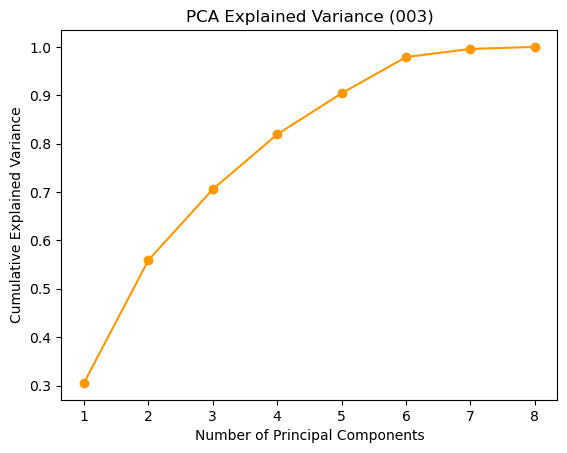

In [9]:
# PCA
X_003=predata_003.drop(columns=['time','TREFMXAV_U','lat','lon','year','month','day','dayofyear'])
scaler=StandardScaler()
pca=PCA()
X_scaled_003=scaler.fit_transform(X_003)
X_pca_003=pca.fit_transform(X_scaled_003)
print(pca.explained_variance_ratio_)

var_ratio_003=pca.explained_variance_ratio_
cum_var_003=np.cumsum(var_ratio_003)

plt.plot(range(1,9),cum_var_003,marker='o',color='#FF9800')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance (003)')
plt.show()


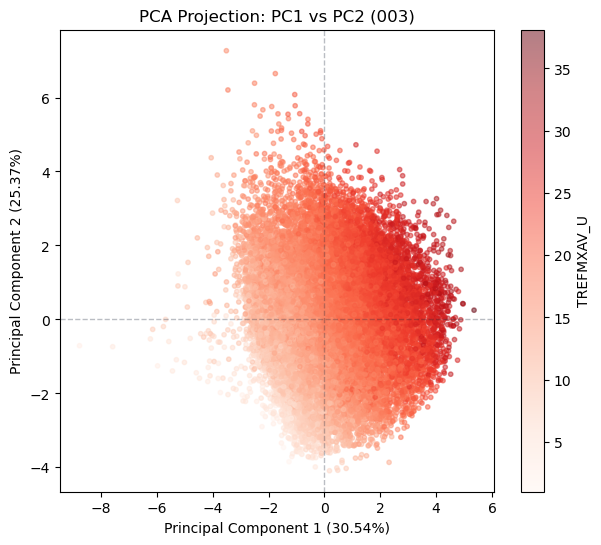

In [27]:
# PCA 2 components
pca2=PCA(n_components=2)
X_pca2_003=pca2.fit_transform(X_scaled_003)

pca2_003=pd.DataFrame(X_pca2_003,columns=['PC1','PC2'])
pca2_003['TREFMXAV_U']=predata_003['TREFMXAV_U']

plt.figure(figsize=(7,6))
pca2_003_scatter=plt.scatter(pca2_003['PC1'],pca2_003['PC2'],c=pca2_003['TREFMXAV_U'],cmap='Reds',alpha=0.5,s=10)
plt.colorbar(pca2_003_scatter, label='TREFMXAV_U')
plt.axhline(0, color='#1B263B', linestyle='--', linewidth=1, alpha=0.3)
plt.axvline(0, color='#1B263B', linestyle='--', linewidth=1, alpha=0.3)

plt.xlabel(f'Principal Component 1 ({var_ratio_003[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({var_ratio_003[1]:.2%})')
plt.title('PCA Projection: PC1 vs PC2 (003)')

plt.show()


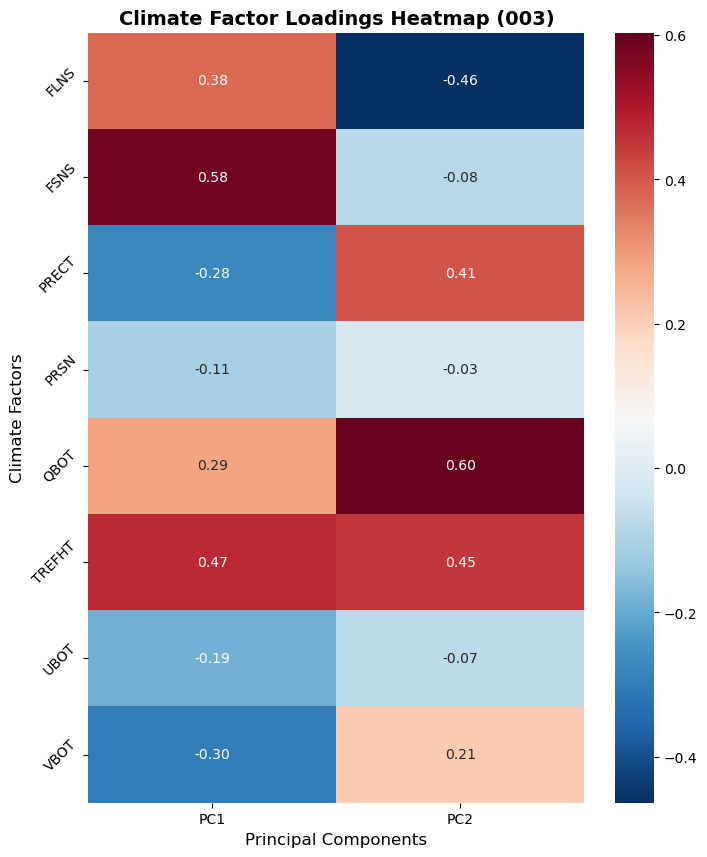

In [34]:
loadings = pd.DataFrame(pca2.components_.T, columns=['PC1', 'PC2'], index=X_003.columns)
loadings

plt.figure(figsize=(8,10))
sns.heatmap(loadings[['PC1','PC2']],annot=True,cmap='RdBu_r',fmt='.2f')
plt.title('Climate Factor Loadings Heatmap (003)',fontsize=14,fontweight='bold')
plt.ylabel('Climate Factors',fontsize=12)
plt.xlabel('Principal Components',fontsize=12)
plt.yticks(rotation=45)

plt.show()

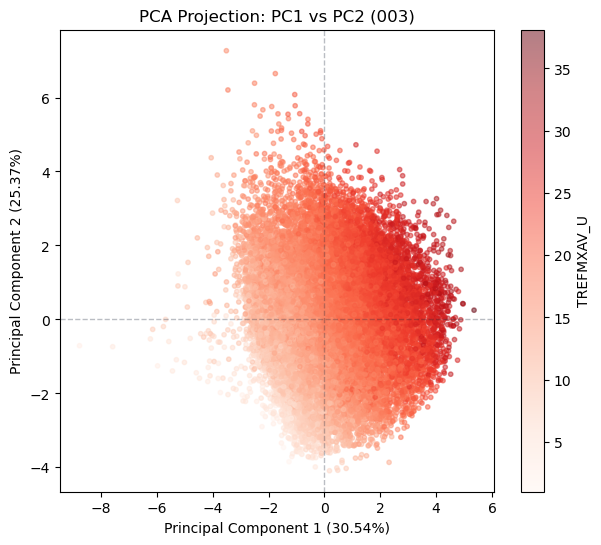

In [28]:
# PCA 4 components
pca4=PCA(n_components=4)
X_pca4_003=pca4.fit_transform(X_scaled_003)

pca4_003=pd.DataFrame(X_pca4_003,columns=['PC1','PC2','PC3','PC4'])
pca4_003['TREFMXAV_U']=predata_003['TREFMXAV_U']

plt.figure(figsize=(7,6))
pca4_003_scatter=plt.scatter(pca4_003['PC1'],pca4_003['PC2'],c=pca4_003['TREFMXAV_U'],cmap='Reds',alpha=0.5,s=10)
plt.colorbar(pca4_003_scatter, label='TREFMXAV_U')
plt.axhline(0, color='#1B263B', linestyle='--', linewidth=1, alpha=0.3)
plt.axvline(0, color='#1B263B', linestyle='--', linewidth=1, alpha=0.3)

plt.xlabel(f'Principal Component 1 ({var_ratio_003[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({var_ratio_003[1]:.2%})')
plt.title('PCA Projection: PC1 vs PC2 (003)')

plt.show()